## CAR - Price - Prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="whitegrid", palette="Set2")

In [3]:
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [5]:
df.shape

(301, 9)

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
# Drop the Duplicated value
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(299, 9)

In [13]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner']

In [14]:
df['Owner'].value_counts()

Owner
0    288
1     10
3      1
Name: count, dtype: int64

In [15]:
df['Car_Name'].value_counts()

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               10
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

In [16]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

In [17]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

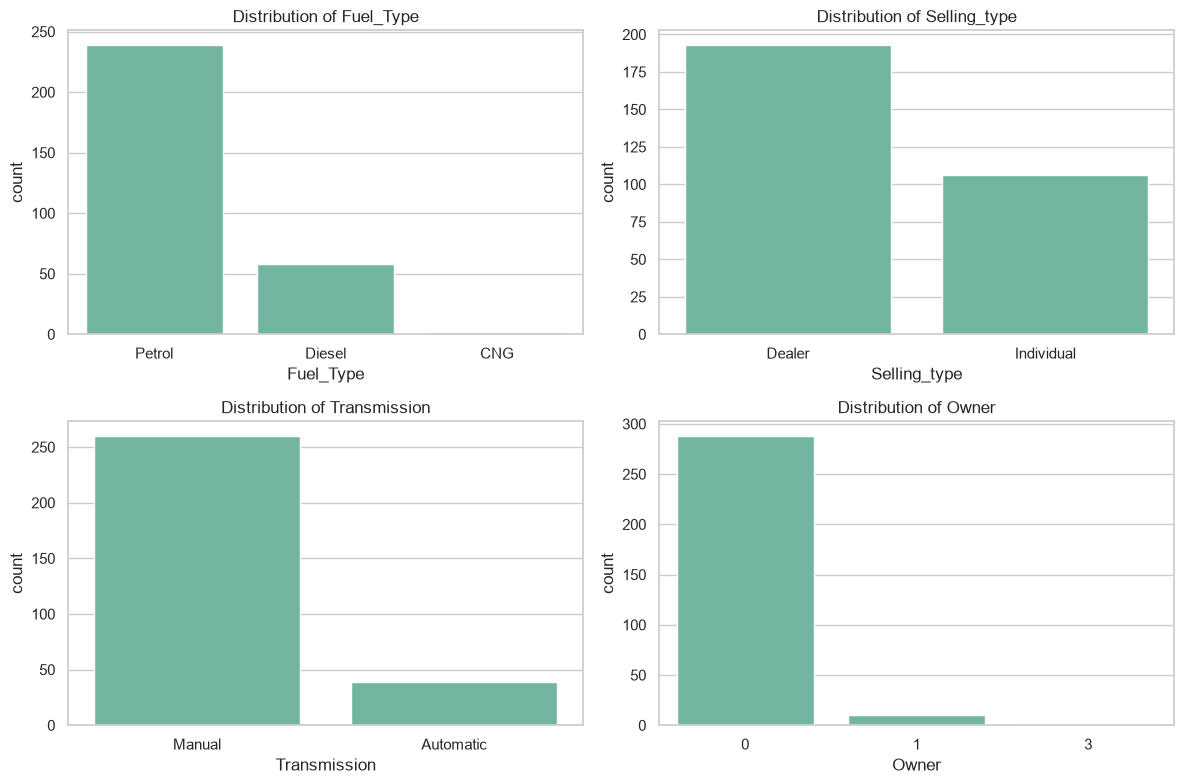

In [18]:
# count plotting on categorical 
cat_col = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

fig , axes = plt.subplots(2 , 2 , figsize = (12 , 8))
for ax , col in zip(axes.flatten() , cat_col):
    sns.countplot(data = df , x = col , ax = ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## EDE

In [19]:
#kde plot of target col
num_col = df.select_dtypes(include= np.number).columns
print(num_col)

Index(['Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Owner'], dtype='str')


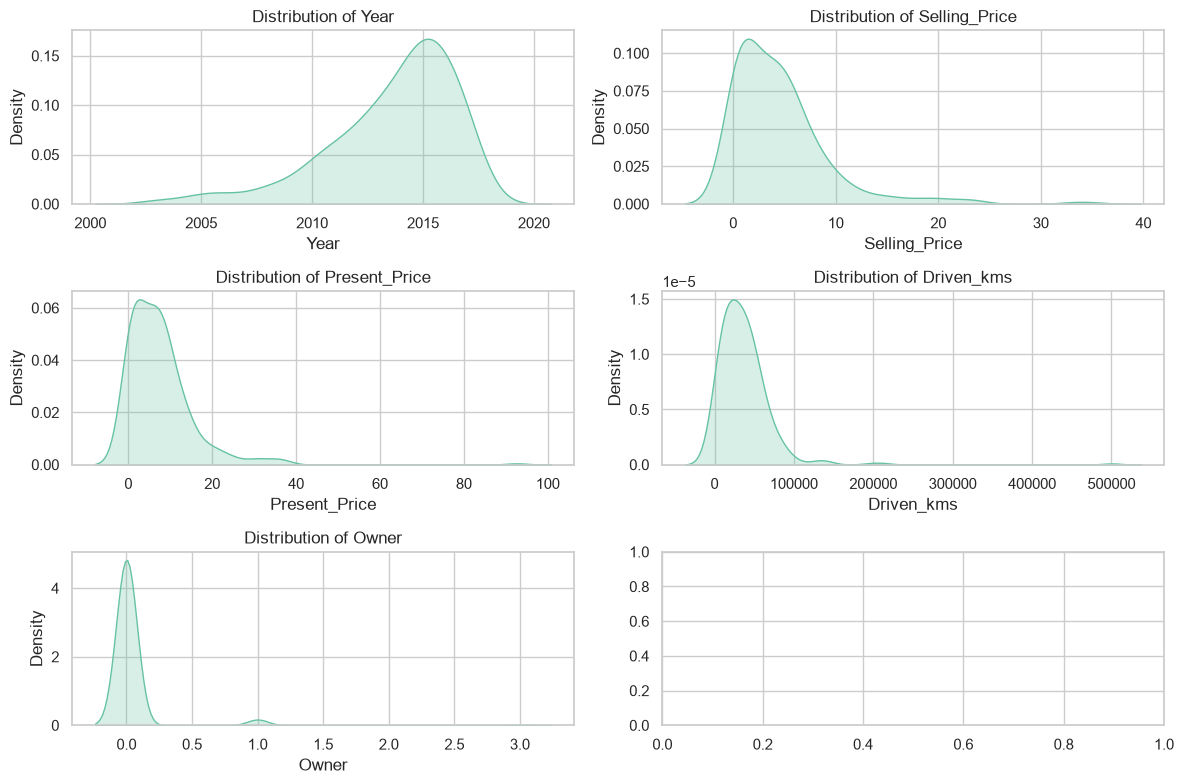

In [20]:
# KDE plot of numerical columns

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_col):
    sns.kdeplot(data=df , x=col, ax=ax, fill=True)
    
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

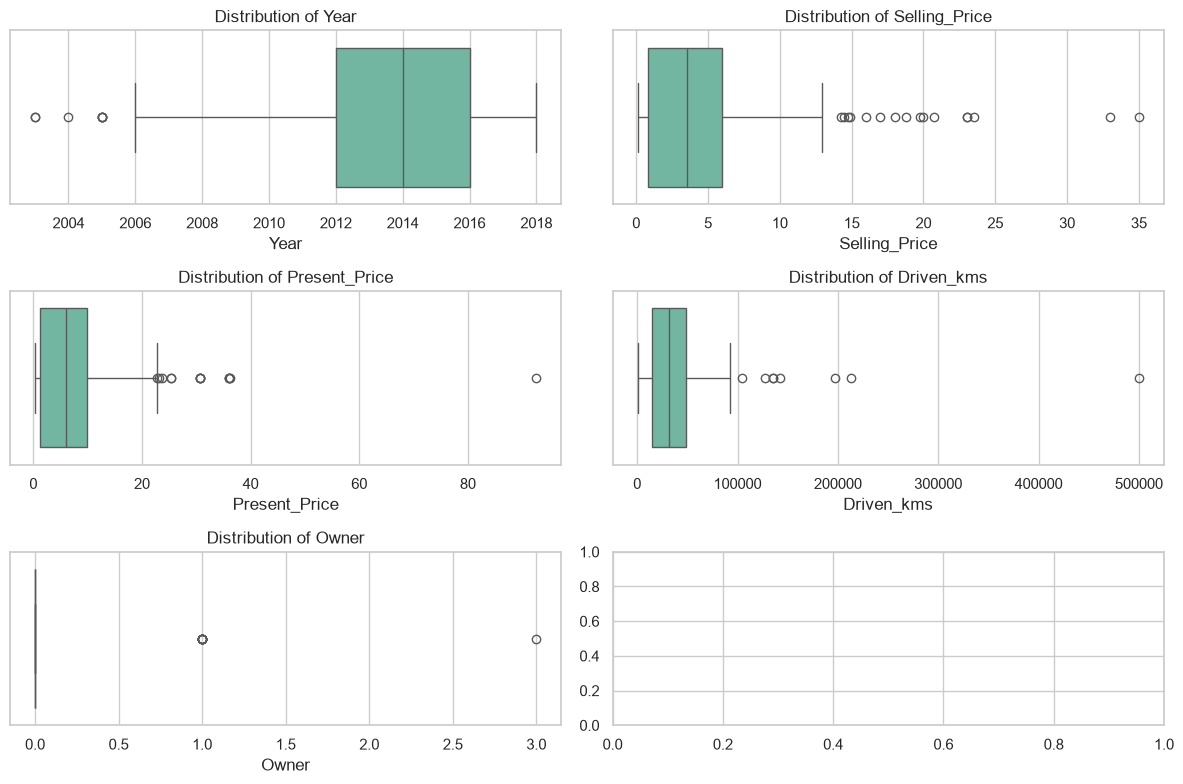

In [21]:
# BoX plot 
fig , axes = plt.subplots(3 , 2 , figsize=(12 , 8))
for ax , col in zip(axes.flatten() , num_col):
    sns.boxplot(data = df , x = col , ax = ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

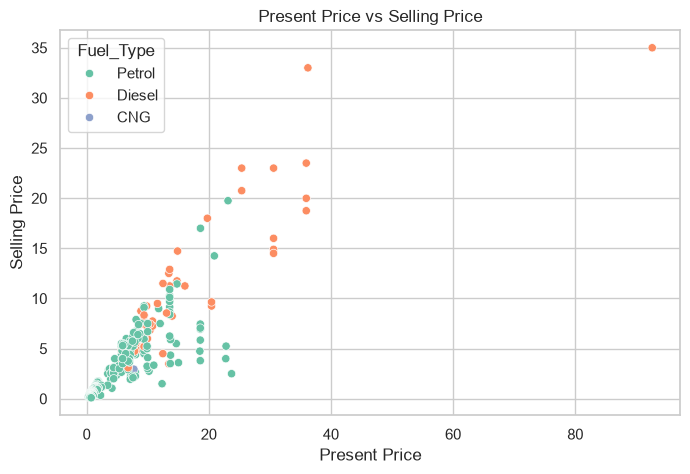

In [22]:
# Present Price vs Selling Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x="Present_Price",y="Selling_Price" , hue = 'Fuel_Type')

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

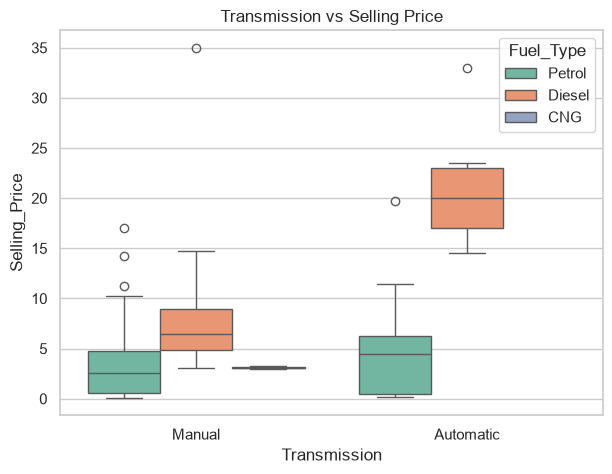

In [23]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price",
    hue = "Fuel_Type"
)

plt.title("Transmission vs Selling Price")

plt.show()

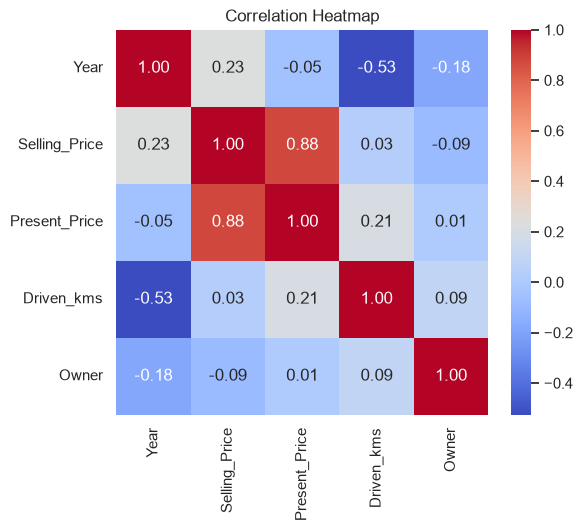

In [24]:
# co- Relation
plt.figure(figsize=(6 ,5))
corr = df.select_dtypes(include= np.number).corr()
sns.heatmap(corr , annot= True , fmt = ".2f" , cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

In [25]:
# Created a New car_age columns and delect the year col
df['Car_Age'] = df['Year'].max() - df['Year']

In [26]:
df['Car_Age'].describe()

count    299.000000
mean       4.384615
std        2.896868
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       15.000000
Name: Car_Age, dtype: float64

In [27]:
df['Car_Age'].head()

0    4
1    5
2    1
3    7
4    4
Name: Car_Age, dtype: int64

In [28]:
df.drop("Year" , axis = 1 , inplace= True)

In [29]:
# also change kms_per_year and delect 
df['kms_Per_Year'] = df['Driven_kms'] / (df['Car_Age'] + 1 )

In [30]:
df['kms_Per_Year'].describe()

count      299.000000
mean      6728.530908
std       4551.802151
min        166.666667
25%       3775.000000
50%       6250.000000
75%       8927.694444
max      45454.545455
Name: kms_Per_Year, dtype: float64

In [31]:
df.columns.to_list()

['Car_Name',
 'Selling_Price',
 'Present_Price',
 'Driven_kms',
 'Fuel_Type',
 'Selling_type',
 'Transmission',
 'Owner',
 'Car_Age',
 'kms_Per_Year']

In [32]:
## Checking Ouliers

In [33]:
num_feature = df.select_dtypes(include= np.number).columns
print("Numrical Col : " , num_feature)

Numrical Col :  Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'kms_Per_Year'],
      dtype='str')


In [34]:
for col in num_feature:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) |(df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Selling_Price: 16 outliers
Present_Price: 14 outliers
Driven_kms: 8 outliers
Owner: 11 outliers
Car_Age: 7 outliers
kms_Per_Year: 7 outliers


In [35]:
# Checking SwekNess
skweness = df[num_feature].skew()
print("SkweNess : \n",skweness.sort_values(ascending = False))

SkweNess : 
 Owner            7.590605
Driven_kms       6.418134
Present_Price    4.189255
kms_Per_Year     2.652111
Selling_Price    2.536522
Car_Age          1.236876
dtype: float64


In [36]:
# After the skewness value 
# i will perfome on log1p Tranformation on Present_Price , Driven_kms , kms_Per_Year
# i will not on selling cuz its my traget and i will be stay on natural.
# owner are not 3 value the its 0 is very high fequnce and Car_Age -> Its skewness is moderate, so leave it alone.

In [37]:
#apply log1p
df_model = df.copy()

# df_model['Present_Price'] = np.log1p(df_model['Present_Price']) -> log1p used by sklearn alorithum on pipeline.
# df_model['Driven_kms'] = np.log1p(df_model['Driven_kms'])
# df_model['kms_Per_Year'] = np.log1p(df_model['kms_Per_Year'])

In [38]:
#checking result after log1p
num_log_col = df_model.select_dtypes(include=np.number).columns

skewness_after = df_model[num_log_col].skew()
print(skewness_after.sort_values(ascending=False))

Owner            7.590605
Driven_kms       6.418134
Present_Price    4.189255
kms_Per_Year     2.652111
Selling_Price    2.536522
Car_Age          1.236876
dtype: float64


In [39]:
'''
Driven_kms  & Kms_Per_Year -> The transformation over-corrected it. Don't use the log version.
Present_Price -> Keep the log transformation.
'''

"\nDriven_kms  & Kms_Per_Year -> The transformation over-corrected it. Don't use the log version.\nPresent_Price -> Keep the log transformation.\n"

## Train test Split

In [40]:
# Identify numerical and categorical features
numerical_col = df_model.select_dtypes(include = np.number).columns
categorical_col = df_model.select_dtypes(include = np.object_).columns

print("Numerical Col :" , numerical_col.to_list())
print("Categorical :" , categorical_col.to_list())

Numerical Col : ['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'kms_Per_Year']
Categorical : ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [41]:
from sklearn.model_selection import train_test_split

skew_col = ['Present_Price']

num_features = ["Driven_kms","Owner","Car_Age","kms_Per_Year"]

ordinal_features = ["Selling_type","Transmission","Fuel_Type"]

onehot_features = ["Car_Name"]

features_col = skew_col + num_features + ordinal_features + onehot_features
x = df[features_col]
y = df['Selling_Price']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size= 0.2 , random_state= 42 , shuffle= True)

In [42]:
#cheking
print("X Shape :" , x.shape)
print("y Shape :" , y.shape)

print("\nFeatures:")
print(x.columns.tolist())

print("\nTarget:")
print(y.name)

#chekking
print("\nX_train Shape : " , x_train.shape)
print("X_test Shape : " , x_test.shape)
print("y_train Shape : " , y_train.shape)
print("X_test Shape : " , x_test.shape)

X Shape : (299, 9)
y Shape : (299,)

Features:
['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'kms_Per_Year', 'Selling_type', 'Transmission', 'Fuel_Type', 'Car_Name']

Target:
Selling_Price

X_train Shape :  (239, 9)
X_test Shape :  (60, 9)
y_train Shape :  (239,)
X_test Shape :  (60, 9)


## Preprocessing & Columns Transnformation

In [43]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder , LabelEncoder , OrdinalEncoder , FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pipeline_skew = Pipeline(steps=[
    ("log transform" , FunctionTransformer(np.log1p)),
    ("scale" , StandardScaler())
])

pipeline_num = Pipeline(steps=[
    ("scale" , StandardScaler())
])

pipeline_odinal = Pipeline(steps=[
    ("ordinal" , OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))
])

pipeline_onehot = Pipeline(steps=[
    ("onehot" , OneHotEncoder(handle_unknown= 'ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skew_Pipeline" , pipeline_skew , skew_col),
    ("Num_Pipeline" , pipeline_num , num_features),
    ("ordinal_pipeline" , pipeline_odinal , ordinal_features),
    ("OneHot" , pipeline_onehot , onehot_features),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skew_Pipeline', ...), ('Num_Pipeline', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_nam

In [44]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)

print("X Train transformed shape:", x_train_transformed.shape)
print("X Test transformed shape:", x_test_transformed.shape)

X Train transformed shape: (239, 93)
X Test transformed shape: (60, 93)


## Model Testing At Different Algo.

In [64]:
# Algorithums to Train The Model
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Metrix
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

# Model Selection
from sklearn.model_selection import cross_val_score , RandomizedSearchCV
from scipy.stats import randint, uniform

In [53]:
#training the model
regression = {
    "Linear Regression : " : LinearRegression(),
    "Ridge : "             : Ridge(alpha=1.0),
    "Lasso : "             : Lasso(alpha=0.001, max_iter=10000),
    "Decision Tree : "     : DecisionTreeRegressor(max_depth=8,min_samples_split=4, min_samples_leaf=2, random_state=42),
    "Random Forest : "     : RandomForestRegressor(n_estimators=500, max_depth=12, min_samples_split=2, min_samples_leaf=1, max_features=0.8, random_state=42, n_jobs=-1),
    "Gardient Boosting : " : GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=3, min_samples_split=3, min_samples_leaf=2, subsample=0.9, random_state=42),
    "SVR : "               : SVR( kernel="rbf", C=100, epsilon=0.05, gamma="scale"),
    "XGBoost : "           : XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=4, min_child_weight=2, subsample=0.9, colsample_bytree=0.9, reg_alpha=0.01, reg_lambda=1.0, objective="reg:squarederror", random_state=42, n_jobs=-1)
}
#pipeline of all algo.
pipeline_reg = {
    name: Pipeline(steps = [
        ("preprocession" , preprocessor),
        ("model" , reg),
    ])
    for name , reg in regression.items()
}


In [54]:
#add all value in result 
result = []

for name , pipeline in pipeline_reg.items():
    pipeline.fit(x_train , y_train)
    y_pred = pipeline.predict(x_test)

    cv_score = cross_val_score(pipeline , x_train , y_train , cv = 5 , scoring= 'r2')

    result.append({
        "Model"       : name,
        "R2 Score"    : r2_score(y_test , y_pred),
        "MAE-Score"   : mean_absolute_error(y_test, y_pred),
        "RMSE"        : np.sqrt(mean_squared_error(y_test , y_pred)),
        "MSE-Score"   : mean_squared_error(y_test, y_pred),

        "CV_Mean R2"  : cv_score.mean(),
        "CV_STD"      : cv_score.std(),
    })

In [55]:
# Printing the avalue
result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by = "CV_Mean R2" , ascending=False).reset_index(drop = True)

result_df

,Model,R2 Score,MAE-Score,RMSE,MSE-Score,CV_Mean R2,CV_STD
0,Random Forest :,0.568970,1.395658,3.333023,11.109043,0.888395,0.102410
1,Decision Tree :,0.823727,1.060594,2.131464,4.543140,0.879671,0.048433
2,XGBoost :,0.702580,1.131816,2.768659,7.665473,0.866445,0.085903
3,Gardient Boosting :,0.618039,1.281019,3.137576,9.844381,0.860607,0.099583
4,SVR :,0.845451,0.944909,1.995801,3.983220,0.824372,0.172949
5,Ridge :,0.548976,1.962390,3.409450,11.624349,0.815737,0.068079
6,Lasso :,0.612548,1.748044,3.160048,9.985905,0.785197,0.070664
7,Linear Regression :,0.418638,2.407099,3.870865,14.983595,0.720632,0.143527


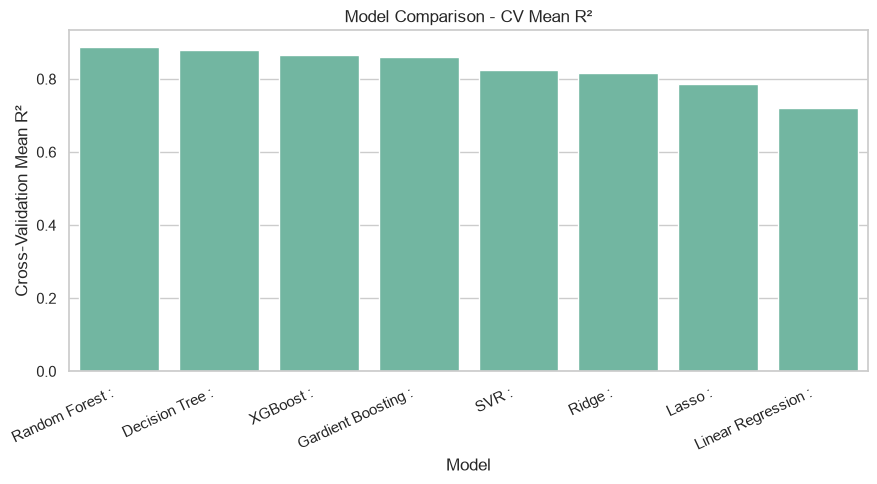

In [56]:
# Visual comparison of model performance
plt.figure(figsize=(9, 5))

sns.barplot(
    data=result_df,
    x="Model",
    y="CV_Mean R2"
)

plt.xticks(rotation=25, ha="right")
plt.xlabel("Model")
plt.ylabel("Cross-Validation Mean R²")
plt.title("Model Comparison - CV Mean R²")

plt.tight_layout()
plt.show()

In [57]:
# Select best model based ONLY on Cross-Validation Mean R2
best_model_name = result_df.loc[result_df["CV_Mean R2"].idxmax(),"Model"]
best_pipeline = pipeline_reg[best_model_name]

best_cv_r2 = result_df.loc[result_df["CV_Mean R2"].idxmax(), "CV_Mean R2"]

best_cv_std = result_df.loc[result_df["CV_Mean R2"].idxmax(),"CV_STD"]

print("BEST MODEL")
print(f"Model      : {best_model_name}")
print(f"CV_Mean R2 : {best_cv_r2:.4f}")
print(f"CV STD     : {best_cv_std:.4f}")

BEST MODEL
Model      : Random Forest : 
CV_Mean R2 : 0.8884
CV STD     : 0.1024


In [60]:
#selcting model ----> RFR
best_model_name = result_df.loc[result_df["CV_Mean R2"].idxmax(),"Model"]
best_pipeline = pipeline_reg[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest : 


In [61]:
y_pred_best = best_pipeline.predict(x_test)

print("First 10 Predictions:")
print(y_pred_best[:10])

First 10 Predictions:
[ 9.34477764  8.14957198  0.45039872  7.0991159  16.533       5.32571549
  6.37560667  1.20690167  7.94225113  0.34639724]


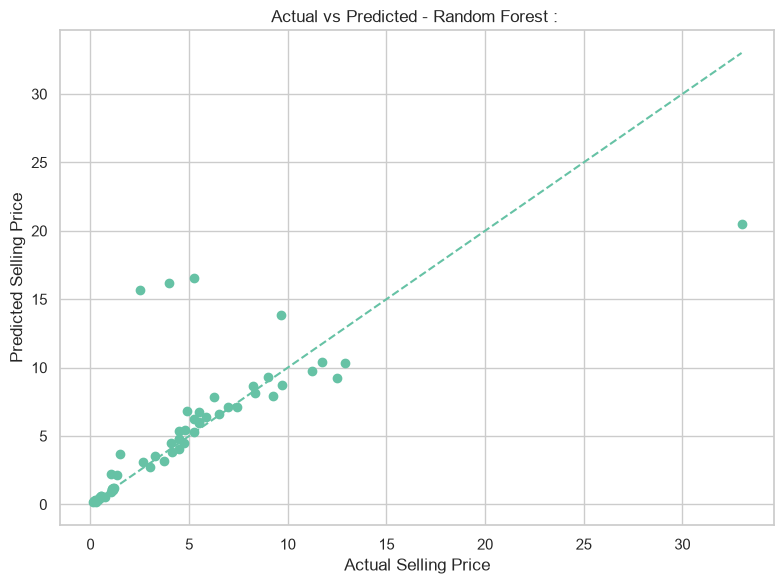

In [62]:
#graph Between Acutal and Predition 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [65]:
rf = RandomForestRegressor(random_state=42,n_jobs=-1)

param_grid = {
    "model__n_estimators": randint(200, 1000),
    "model__max_depth": [None, 5, 8, 10, 12, 15, 20, 25],
    "model__min_samples_split": randint(2, 10),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": ["sqrt", "log2", 0.5, 0.7, 0.8, 1.0]
}

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': <scipy.stats....001DA4548DA90>, 'model__min_samples_split': <scipy.stats....001DA4548D810>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score in

In [66]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV R2:")
print(f"{rf_search.best_score_:.4f}")

Best Parameters:
{'model__max_depth': 12, 'model__max_features': 0.8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 720}

Best CV R2:
0.8889


In [67]:
best_model = rf_search.best_estimator_

y_pred = best_model.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("TUNED RANDOM FOREST")
print(f"CV Mean R2 : {rf_search.best_score_:.4f}")
print(f"Test R2    : {r2:.4f}")
print(f"MAE        : {mae:.4f} Lakhs")
print(f"RMSE       : {rmse:.4f} Lakhs")

TUNED RANDOM FOREST
CV Mean R2 : 0.8889
Test R2    : 0.5806
MAE        : 1.3785 Lakhs
RMSE       : 3.2878 Lakhs


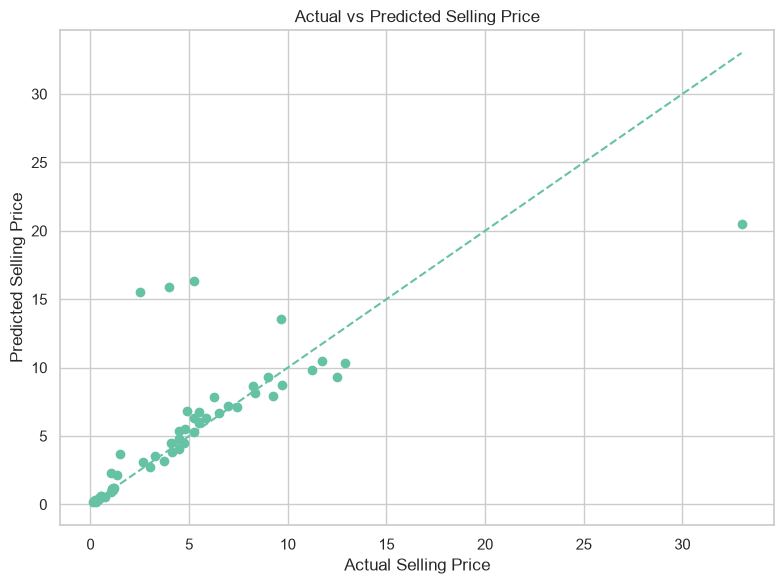

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.tight_layout()
plt.show()

In [73]:
## Save the Model

In [74]:
import joblib

joblib.dump(best_model, "car_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
